# Анализ эффективности классических моделей машинного обучения на обработанных и необработанных текстовых данных

In [1]:
import pandas as pd
import numpy as np
import kagglehub
import os


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Функции для вывода результатов

In [2]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    print(f"Матрица ошибок для {title}:")
    print(cm)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Предсказано')
    plt.ylabel('Фактически')
    plt.title(f'Матрица ошибок {title}')
    plt.show()


In [3]:
def evaluate_model(y_true, y_pred, title):
    print(f"\n{title}")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1-score :", round(f1_score(y_true, y_pred), 4))
    print("\nОтчёт по классам:\n", classification_report(y_true, y_pred))


## Считываем данные

In [4]:
# Download latest version
path = kagglehub.dataset_download("aunanya875/suicidal-tweet-detection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/albertzagibin/.cache/kagglehub/datasets/aunanya875/suicidal-tweet-detection-dataset/versions/1


In [5]:
df_ = pd.read_csv(path+'/Suicide_Ideation_Dataset(Twitter-based).csv')
df_.head()

,Tweet,Suicide
0,making some lunch,Not Suicide post
1,@Alexia You want his money.,Not Suicide post
2,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post
3,@jnaylor #kiwitweets Hey Jer! Since when did y...,Not Suicide post
4,Trying out &quot;Delicious Library 2&quot; wit...,Not Suicide post


### Обработка пустых значений

In [6]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1787 entries, 0 to 1786
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Tweet    1785 non-null   object
 1   Suicide  1787 non-null   object
dtypes: object(2)
memory usage: 28.1+ KB


In [7]:
df_['Tweet'].isna().sum()

np.int64(2)

In [8]:
df_.dropna(inplace=True)

### Баланс классов

<Axes: >

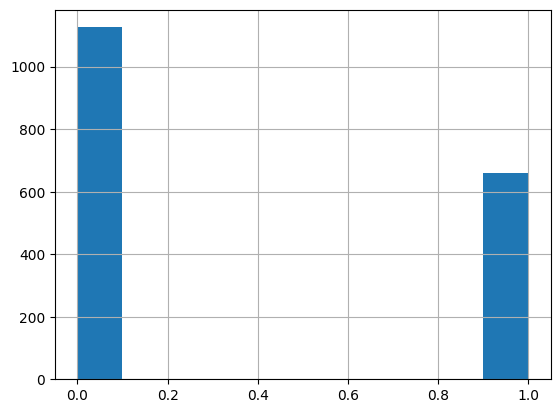

In [9]:
# посмотрим на баланс классов 
(df_['Suicide'] == 'Potential Suicide post ').astype(int).hist()

In [10]:
df_clear = df_.copy()

### Приведение к нижнему регистру

In [11]:
df_clear.head(5)

,Tweet,Suicide
0,making some lunch,Not Suicide post
1,@Alexia You want his money.,Not Suicide post
2,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post
3,@jnaylor #kiwitweets Hey Jer! Since when did y...,Not Suicide post
4,Trying out &quot;Delicious Library 2&quot; wit...,Not Suicide post


In [12]:
#привести текст к нижнему регистру
df_clear['Tweet'] = df_clear['Tweet'].str.lower()
df_clear.head(1)


,Tweet,Suicide
0,making some lunch,Not Suicide post


### Обработка HTML-сущностей

In [13]:
df_clear['Tweet'] = df_clear['Tweet'].str.replace(r'&[^;\s]+;', '', regex=True)
df_clear.head(5)

,Tweet,Suicide
0,making some lunch,Not Suicide post
1,@alexia you want his money.,Not Suicide post
2,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post
3,@jnaylor #kiwitweets hey jer! since when did y...,Not Suicide post
4,trying out delicious library 2 with mixed resu...,Not Suicide post


### Убираем ссылки

In [14]:
# Проверка: есть ли ссылки
urls_exist = df_clear['Tweet'].str.contains(r'http\S+|www\S+', regex=True).sum()
print("Количество текстов с ссылками:", urls_exist)


Количество текстов с ссылками: 293


In [15]:
# Если есть, удаляем
df_clear['Tweet'] = df_clear['Tweet'].str.replace(r'http\S+|www\S+', '', regex=True)
urls_exist = df_clear['Tweet'].str.contains(r'http\S+|www\S+', regex=True).sum()
print("Количество текстов с ссылками:", urls_exist)

Количество текстов с ссылками: 0


### Убираем цифры

In [16]:
# Проверка: есть ли цифры
digits_exist = df_clear['Tweet'].str.contains(r'\d+', regex=True).sum()
print("Количество текстов с цифрами:", digits_exist)

Количество текстов с цифрами: 338


In [17]:
# Если есть, удаляем
df_clear['Tweet'] = df_clear['Tweet'].str.replace(r'\d+', '', regex=True)

In [18]:
df_clear.head()

,Tweet,Suicide
0,making some lunch,Not Suicide post
1,@alexia you want his money.,Not Suicide post
2,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post
3,@jnaylor #kiwitweets hey jer! since when did y...,Not Suicide post
4,trying out delicious library with mixed resul...,Not Suicide post


### Удаляем хештеги и теги аккаунтов

In [19]:
# # или хештеги стоит оставить?
# df_clear['Tweet'] = df_clear['Tweet'].str.replace(r'[@]\S+', ' ', regex=True)
# df_clear.head(5)

### Удаление всего, кроме букв

In [20]:
# Удаляем всё, кроме букв и пробелов (оставляем только a-z и пробелы)
df_clear['Tweet'] = df_clear['Tweet'].str.replace(r'[^a-z\s]', ' ', regex=True)

In [21]:
df_clear['Tweet'].head(10)

0                                    making some lunch
1                           alexia you want his money 
2     dizzyhrvy that crap took me forever to put to...
3     jnaylor  kiwitweets hey jer  since when did y...
4    trying out delicious library  with mixed resul...
5     valenvaldez oh  that s good to hear  but is i...
6     mcm u ve got a list for fellow  hotties  you ...
7     jakepaul  jamescharles  loganpaul just becaus...
8            time for some warsaw beer garden chilling
9    i hate my life lmao i hope i die soon or sumn ...
Name: Tweet, dtype: object

### Убираем двойные пробелы

In [22]:
df_clear['Tweet'] = df_clear['Tweet'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [23]:
df_clear['Tweet'].head(10)

0                                    making some lunch
1                            alexia you want his money
2    dizzyhrvy that crap took me forever to put tog...
3    jnaylor kiwitweets hey jer since when did you ...
4    trying out delicious library with mixed result...
5    valenvaldez oh that s good to hear but is it o...
6    mcm u ve got a list for fellow hotties you gon...
7    jakepaul jamescharles loganpaul just because s...
8            time for some warsaw beer garden chilling
9    i hate my life lmao i hope i die soon or sumn ...
Name: Tweet, dtype: object

### Убираем дубли

In [24]:
df_clear.duplicated().sum()

np.int64(10)

In [25]:
df_clear.drop_duplicates(inplace=True)

In [26]:
df_clear.duplicated().sum()

np.int64(0)

### Обработка стоп слов

In [27]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Разбиваем на слова, удаляем стоп-слова, собираем обратно
df_clear['Tweet'] = df_clear['Tweet'].apply(
    lambda text: ' '.join([word for word in text.split() if word not in stop_words])
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/albertzagibin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
df_['Tweet'][4]

'Trying out &quot;Delicious Library 2&quot; with mixed results The bar code thought I wanted to add a sport bra instead of a drill Cool app tho!'

In [29]:
df_clear['Tweet'][4]

'trying delicious library mixed results bar code thought wanted add sport bra instead drill cool app tho'

### Лемматизация

In [30]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized = []
    for word in words:
        # Сначала пробуем как глагол
        lemma_v = lemmatizer.lemmatize(word, pos='v')
        # Если не изменилось — значит, это не глагол (или уже лемма)
        if lemma_v != word:
            lemmatized.append(lemma_v)
        else:
            # Иначе пробуем как существительное (по умолчанию)
            lemmatized.append(lemmatizer.lemmatize(word))
    return ' '.join(lemmatized)

df_clear['lemmatized'] = df_clear['Tweet'].apply(lemmatize_text)

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/albertzagibin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [31]:
df_clear['lemmatized'][4]

'try delicious library mix result bar code think want add sport bra instead drill cool app tho'

In [32]:
df = df_clear[['Tweet', 'Suicide']].copy()
df['Clean_Tweet'] = df_clear['lemmatized']
df['Raw_Tweet'] = df_['Tweet']

In [33]:
df[df['Clean_Tweet'].apply(len) == 0]

,Tweet,Suicide,Clean_Tweet,Raw_Tweet
316,,Potential Suicide post,,https://t.co/6MPqRunPeX https://t.co/6MPqRunPeX


In [34]:
# Удаляем строки с пустыми твитами
df = df[df['Clean_Tweet'].apply(len) > 0]
print("Количество строк после удаления пустых твитов:", len(df))

Количество строк после удаления пустых твитов: 1774


In [35]:
df[['Clean_Tweet', 'Raw_Tweet', 'Suicide']].head()

,Clean_Tweet,Raw_Tweet,Suicide
0,make lunch,making some lunch,Not Suicide post
1,alexia want money,@Alexia You want his money.,Not Suicide post
2,dizzyhrvy crap take forever put together go go...,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post
3,jnaylor kiwitweets hey jer since start twitter,@jnaylor #kiwitweets Hey Jer! Since when did y...,Not Suicide post
4,try delicious library mix result bar code thin...,Trying out &quot;Delicious Library 2&quot; wit...,Not Suicide post


### Обучение моделей и сравнение

In [36]:
y = (df['Suicide'] == 'Potential Suicide post ').astype(int)
X_raw = df['Raw_Tweet']
X_clean = df['Clean_Tweet']


X_raw_train, X_raw_test, X_clean_train, X_clean_test, y_train, y_test = train_test_split(
    X_raw, X_clean, y, test_size=0.2, random_state=42, stratify=y
)


In [37]:
X_raw_train[:3]

1071    schÃ¯Â¿Â½nes Marketingwort: Stimulus Package h...
1556    iâm tired of struggling, im tired of asking ...
121     @sandieb321 We are not fussy about age here as...
Name: Raw_Tweet, dtype: object

In [38]:
X_clean_train[:3]

1071                sch ne marketingwort stimulus package
1556    tire struggle im tire ask help mostly tire lif...
121         sandieb fussy age long female change rule lol
Name: Clean_Tweet, dtype: object

In [39]:
vectorizer_raw = TfidfVectorizer(max_features=5000)
X_train_raw_vec = vectorizer_raw.fit_transform(X_raw_train)
X_test_raw_vec = vectorizer_raw.transform(X_raw_test)

vectorizer_clean = TfidfVectorizer(max_features=5000)
X_train_clean_vec = vectorizer_clean.fit_transform(X_clean_train)
X_test_clean_vec = vectorizer_clean.transform(X_clean_test)


### Случайный лес

In [40]:
clf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
clf_raw.fit(X_train_raw_vec, y_train)

clf_clean = RandomForestClassifier(n_estimators=100, random_state=42)
clf_clean.fit(X_train_clean_vec, y_train)

y_pred_raw = clf_raw.predict(X_test_raw_vec)
y_pred_clean = clf_clean.predict(X_test_clean_vec)


In [41]:
evaluate_model(y_test, y_pred_raw, "Модель на сыром тексте (Raw_Tweet)")
evaluate_model(y_test, y_pred_clean, "Модель на очищенном тексте (Clean_Tweet)")


Модель на сыром тексте (Raw_Tweet)
Accuracy : 0.9296
Precision: 0.9339
Recall   : 0.8692
F1-score : 0.9004

Отчёт по классам:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       225
           1       0.93      0.87      0.90       130

    accuracy                           0.93       355
   macro avg       0.93      0.92      0.92       355
weighted avg       0.93      0.93      0.93       355


Модель на очищенном тексте (Clean_Tweet)
Accuracy : 0.9324
Precision: 0.9417
Recall   : 0.8692
F1-score : 0.904

Отчёт по классам:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       225
           1       0.94      0.87      0.90       130

    accuracy                           0.93       355
   macro avg       0.93      0.92      0.93       355
weighted avg       0.93      0.93      0.93       355



Матрица ошибок для Raw Tweet:
[[217   8]
 [ 17 113]]


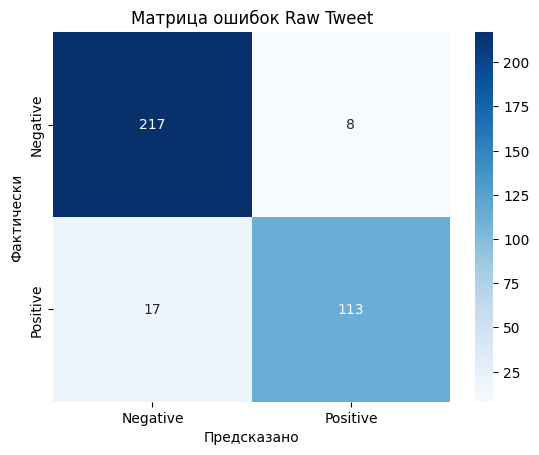

Матрица ошибок для Clean Tweet:
[[218   7]
 [ 17 113]]


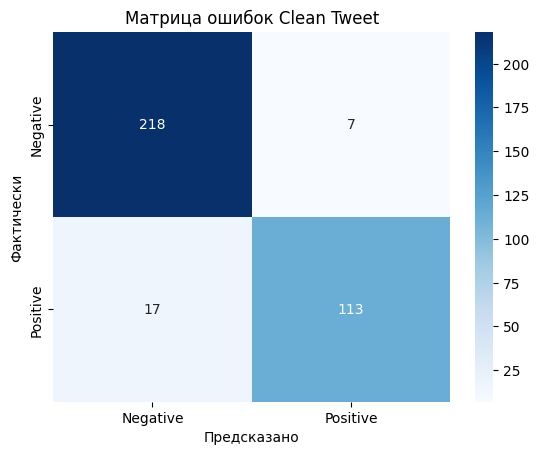

In [42]:
plot_confusion_matrix(y_test, y_pred_raw, "Raw Tweet")
plot_confusion_matrix(y_test, y_pred_clean, "Clean Tweet")

### XGBoost

In [43]:
clf_raw = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
clf_raw.fit(X_train_raw_vec, y_train)

clf_clean = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
clf_clean.fit(X_train_clean_vec, y_train)

y_pred_raw = clf_raw.predict(X_test_raw_vec)
y_pred_clean = clf_clean.predict(X_test_clean_vec)

/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [10:34:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/albertzagibin/Documents/University/ML/venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [10:34:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [44]:
evaluate_model(y_test, y_pred_raw, "Модель на сыром тексте (Raw_Tweet)")
evaluate_model(y_test, y_pred_clean, "Модель на очищенном тексте (Clean_Tweet)")


Модель на сыром тексте (Raw_Tweet)
Accuracy : 0.9437
Precision: 0.9435
Recall   : 0.9
F1-score : 0.9213

Отчёт по классам:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       225
           1       0.94      0.90      0.92       130

    accuracy                           0.94       355
   macro avg       0.94      0.93      0.94       355
weighted avg       0.94      0.94      0.94       355


Модель на очищенном тексте (Clean_Tweet)
Accuracy : 0.9183
Precision: 0.904
Recall   : 0.8692
F1-score : 0.8863

Отчёт по классам:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94       225
           1       0.90      0.87      0.89       130

    accuracy                           0.92       355
   macro avg       0.92      0.91      0.91       355
weighted avg       0.92      0.92      0.92       355



Матрица ошибок для Raw Tweet:
[[218   7]
 [ 13 117]]


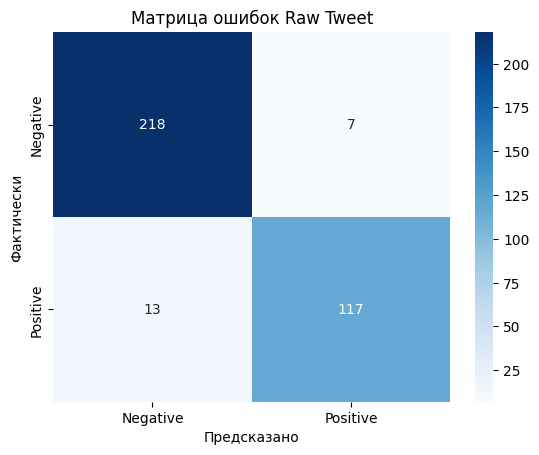

Матрица ошибок для Clean Tweet:
[[213  12]
 [ 17 113]]


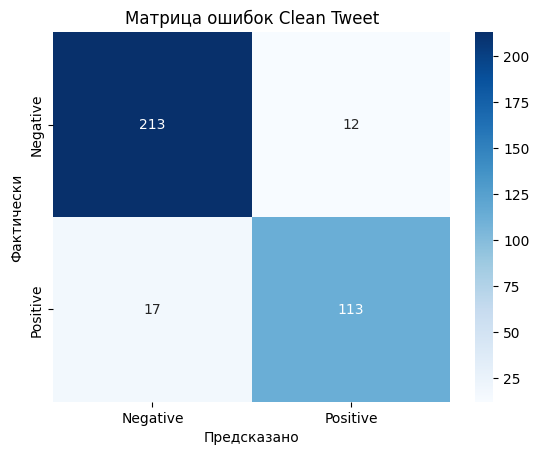

In [45]:
plot_confusion_matrix(y_test, y_pred_raw, "Raw Tweet")
plot_confusion_matrix(y_test, y_pred_clean, "Clean Tweet")